### Imports

In [1]:
# data manipulation
import pandas as pd
import numpy as np

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# model selection
from sklearn.model_selection import (
    train_test_split,
    cross_validate,
    cross_val_predict
)

# machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# feature importance
from sklearn.inspection import permutation_importance

### Load Dataset

In [2]:
df = pd.read_csv('healthcare_dataset.csv')
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [3]:
df.shape

(55500, 15)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  str    
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  str    
 3   Blood Type          55500 non-null  str    
 4   Medical Condition   55500 non-null  str    
 5   Date of Admission   55500 non-null  str    
 6   Doctor              55500 non-null  str    
 7   Hospital            55500 non-null  str    
 8   Insurance Provider  55500 non-null  str    
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  str    
 12  Discharge Date      55500 non-null  str    
 13  Medication          55500 non-null  str    
 14  Test Results        55500 non-null  str    
dtypes: float64(1), int64(2), str(12)
memory usage: 6.4 MB


### EDA

In [5]:
# unique values
for column in df.columns:
    print(f"Unique values in {column}: {df[column].unique()}")

Unique values in Name: <StringArray>
[     'Bobby JacksOn',       'LesLie TErRy',        'DaNnY sMitH',
       'andrEw waTtS',      'adrIENNE bEll',      'EMILY JOHNSOn',
     'edwArD EDWaRDs', 'CHrisTInA MARtinez',    'JASmINe aGuIlaR',
   'ChRISTopher BerG',
 ...
   'tamAra MCcOrmIck',        'sara TAYloR',     'REbECcA toRReS',
       'JAMes lITTLe',      'CaRl CHaNDlEr',        'JOSepH PaUl',
     'braDleY dAniEL',       'LiSa sIMPsoN',      'RoGER farRELl',
  'kaTheRIne WeBSTer']
Length: 49992, dtype: str
Unique values in Age: [30 62 76 28 43 36 21 20 82 58 72 38 75 68 44 46 63 34 67 48 59 73 51 23
 78 25 33 26 70 57 74 81 49 65 31 22 77 42 24 84 55 40 83 18 27 19 29 61
 80 60 35 79 53 69 47 85 52 37 50 32 54 45 66 39 56 64 71 41 88 17 87 86
 15 16 13 14 89]
Unique values in Gender: <StringArray>
['Male', 'Female']
Length: 2, dtype: str
Unique values in Blood Type: <StringArray>
['B-', 'A+', 'A-', 'O+', 'AB+', 'AB-', 'B+', 'O-']
Length: 8, dtype: str
Unique values in Medical Condi

In [6]:
# duplicate values
df.duplicated().sum()

np.int64(534)

In [7]:
# display duplicate rows
duplicate_rows = df[df.duplicated()]
duplicate_rows

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
50023,Samuel joYCe,56,Male,O+,Arthritis,2022-11-03,Krista Hartman,Thomas-Ballard,UnitedHealthcare,15654.830587,157,Urgent,2022-11-22,Aspirin,Inconclusive
50040,KIMBErly vasqueZ,26,Male,A-,Obesity,2023-10-23,Jennifer Bennett,Cowan Inc,UnitedHealthcare,38142.109678,313,Urgent,2023-11-18,Penicillin,Abnormal
50055,SCoTT tHOrNton,55,Female,B-,Obesity,2021-04-08,Joshua Ingram,Keller LLC,Medicare,30894.904511,455,Urgent,2021-04-15,Aspirin,Abnormal
50070,wiLliam LEe,27,Female,O+,Arthritis,2020-01-31,Lauren Montgomery,Winters-Simon,Cigna,46229.434901,153,Elective,2020-02-13,Lipitor,Normal
50078,chRistOPheR NoRrIs,38,Male,AB-,Arthritis,2023-01-14,Denise Blair,Inc Morales,Medicare,9072.127142,452,Emergency,2023-02-12,Penicillin,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55461,connOR coMPTon,63,Male,A+,Asthma,2021-08-21,Jonathan Allen,"and Willis Mullins, Bowers",Medicare,1936.702824,375,Emergency,2021-09-16,Paracetamol,Normal
55462,alYSsA mIlLER,35,Female,A-,Diabetes,2022-06-30,Ryan Price,Shelton-Gallagher,UnitedHealthcare,2210.460898,289,Elective,2022-07-27,Penicillin,Normal
55464,ChRIs huGHeS,35,Female,AB-,Obesity,2024-02-28,Katelyn Perry,Lyons-Hansen,Blue Cross,11889.154513,128,Emergency,2024-03-14,Paracetamol,Abnormal
55484,keNNEtH alvarez,80,Male,O+,Cancer,2022-05-05,Andrew Conner,Sons Mayo and,Cigna,45653.802310,114,Elective,2022-05-17,Aspirin,Normal


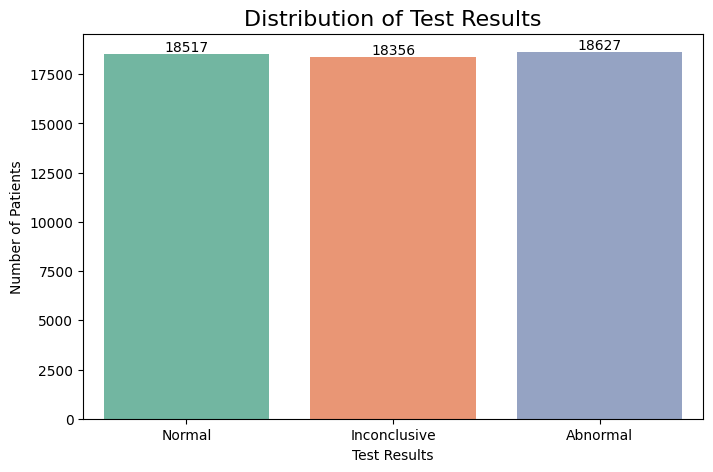

In [8]:
# test results distribution

plt.figure(figsize=(8,5))

ax = sns.countplot(
    x='Test Results',
    hue='Test Results',
    data=df,
    palette='Set2',
    legend=False
)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title('Distribution of Test Results', fontsize=16)
plt.xlabel('Test Results')
plt.ylabel('Number of Patients')

plt.grid(False)

plt.show()

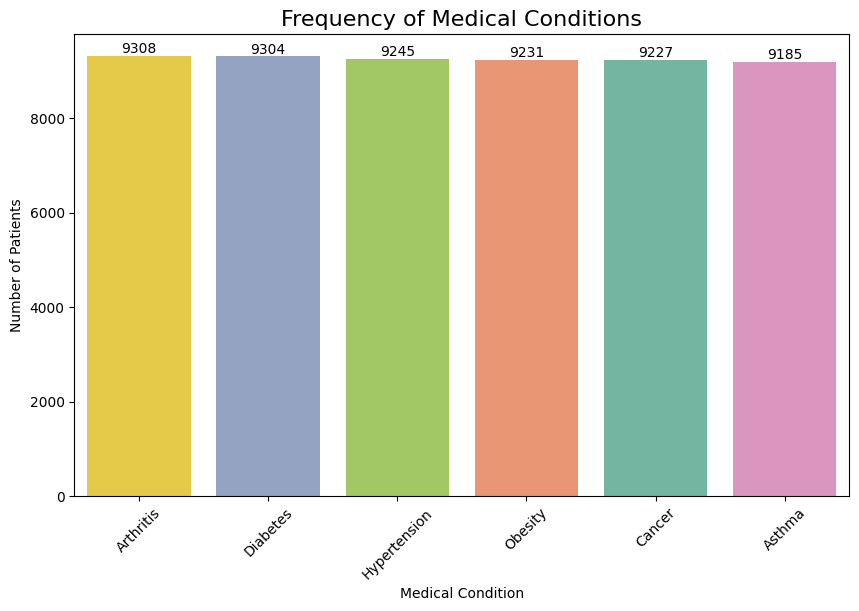

In [9]:
# medical condition frequency

plt.figure(figsize=(10,6))

ax = sns.countplot(
    x='Medical Condition',
    hue='Medical Condition',
    data=df,
    palette='Set2',
    order=df['Medical Condition'].value_counts().index,
    legend=False
)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title('Frequency of Medical Conditions', fontsize=16)
plt.xlabel('Medical Condition')
plt.ylabel('Number of Patients')

plt.xticks(rotation=45)

plt.grid(False)

plt.show()

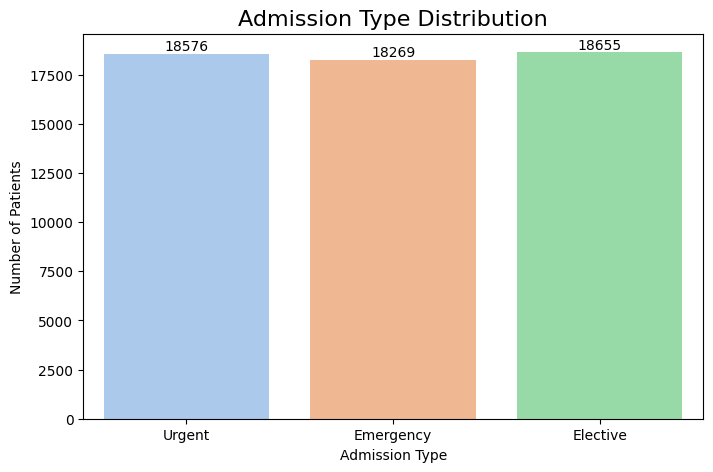

In [10]:
# admission type distribution

plt.figure(figsize=(8,5))

ax = sns.countplot(
    x='Admission Type',
    hue='Admission Type',
    data=df,
    palette='pastel',
    legend=False
)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title('Admission Type Distribution', fontsize=16)
plt.xlabel('Admission Type')
plt.ylabel('Number of Patients')

plt.grid(False)

plt.show()

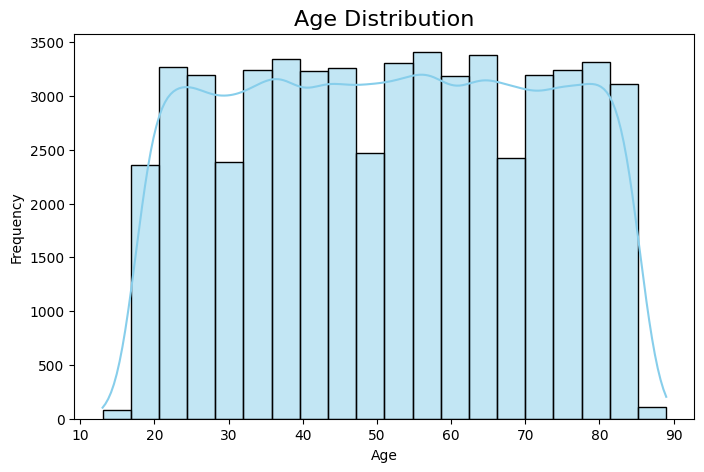

In [11]:
# age distribution

plt.figure(figsize=(8,5))

sns.histplot(
    df['Age'],
    bins=20,
    kde=True,
    color='skyblue'
)

plt.title('Age Distribution', fontsize=16)
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.grid(False)

plt.show()

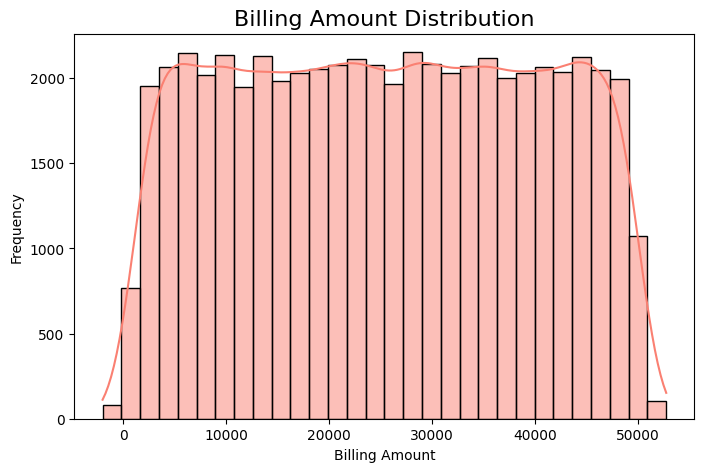

In [12]:
# billing amount distribution

plt.figure(figsize=(8,5))

sns.histplot(
    df['Billing Amount'],
    bins=30,
    kde=True,
    color='salmon'
)

plt.title('Billing Amount Distribution', fontsize=16)
plt.xlabel('Billing Amount')
plt.ylabel('Frequency')

plt.grid(False)

plt.show()

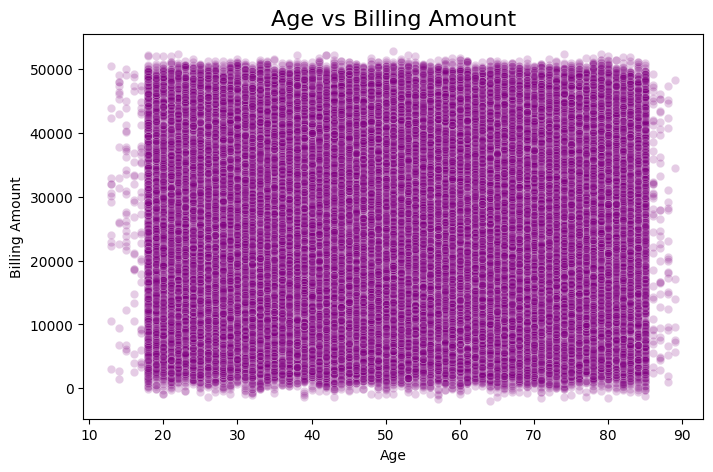

In [13]:
# age vs billing amount

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Age',
    y='Billing Amount',
    data=df,
    alpha=0.2,
    color='purple'
)

plt.title('Age vs Billing Amount', fontsize=16)
plt.xlabel('Age')
plt.ylabel('Billing Amount')

plt.grid(False)

plt.show()

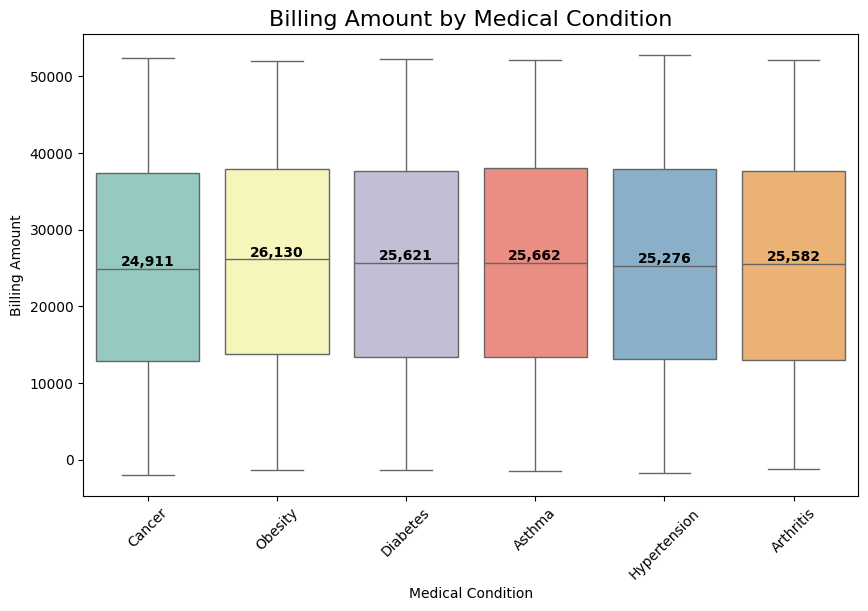

In [14]:
# billing amount by medical condition

plt.figure(figsize=(10,6))

ax = sns.boxplot(
    x='Medical Condition',
    y='Billing Amount',
    hue='Medical Condition',
    data=df,
    palette='Set3',
    legend=False
)

medians = df.groupby('Medical Condition')['Billing Amount'].median()

for i, condition in enumerate(df['Medical Condition'].unique()):

    median_value = medians[condition]

    plt.text(
        i,
        median_value,
        f'{median_value:,.0f}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.xticks(rotation=45)

plt.title('Billing Amount by Medical Condition', fontsize=16)
plt.xlabel('Medical Condition')
plt.ylabel('Billing Amount')

plt.grid(False)

plt.show()

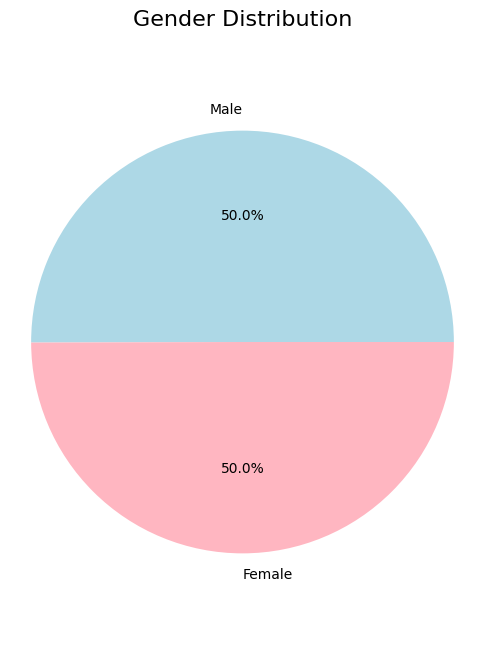

In [15]:
# pie chart for gender distribution

gender_counts = df['Gender'].value_counts()

plt.figure(figsize=(6,8))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    colors=['lightblue', 'lightpink']
)

plt.title('Gender Distribution', fontsize=16)

plt.axis('equal')

plt.show()

### Preprocessing

In [16]:
# change values in column "Name" to lowercase
df['Name'] = df['Name'].str.lower()
# capitalize the first letter of each word in the "Name" column
df['Name'] = df['Name'].str.title()
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,Danny Smith,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,Andrew Watts,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,Adrienne Bell,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [17]:
# change date of admission and Discharge Date dtypes convert to datetime.
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])

In [18]:
# calculate length of stay
df['Length of Stay'] = (df['Discharge Date'] - df['Date of Admission']).dt.days
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Length of Stay
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal,2
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive,6
2,Danny Smith,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal,15
3,Andrew Watts,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal,30
4,Adrienne Bell,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal,20


In [19]:
# drop duplicate rows
df = df.drop_duplicates()
df.shape

(54966, 16)

In [20]:
# detect outliers in Age, Billing Amount, and Length of Stay columns using IQR method
def find_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers

outliers_age = find_outliers_iqr(df, 'Age')
outliers_billing = find_outliers_iqr(df, 'Billing Amount')
outliers_length_of_stay = find_outliers_iqr(df, 'Length of Stay')

print("Outliers in Age:")
print(outliers_age.value_counts())
print("\nOutliers in Billing Amount:")
print(outliers_billing.value_counts())
print("\nOutliers in Length of Stay:")
print(outliers_length_of_stay.value_counts())

Outliers in Age:
Series([], Name: count, dtype: int64)

Outliers in Billing Amount:
Series([], Name: count, dtype: int64)

Outliers in Length of Stay:
Series([], Name: count, dtype: int64)


In [21]:
# prioritize admission type
df['Admission Type'] = df['Admission Type'].replace({'Emergency': 3, 'Urgent': 2, 'Elective': 1})

In [22]:
# drop useless columns
df = df.drop(columns=['Name', 'Doctor', 'Room Number', 'Hospital', 'Date of Admission', 'Discharge Date'])

In [23]:
# reset index after dropping duplicates and columns
df = df.reset_index(drop=True)

In [24]:
# encode gender, blood type, medical condition, insurance provider, and medication columns using dummy encoding
df = pd.get_dummies(df, columns=['Gender', 'Blood Type', 'Medical Condition', 'Insurance Provider', 'Medication'], drop_first=True)

# encode test results columns using label encoding
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df['Test Results'] = label_encoder.fit_transform(df['Test Results'])

# normalize billing amount, length of stay, and age columns using min-max scaling
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df[['Billing Amount', 'Length of Stay', 'Age']] = scaler.fit_transform(df[['Billing Amount', 'Length of Stay', 'Age']])

# convert true and false in all columns to 1 and 0
df = df.replace({True: 1, False: 0})

df.head()

,Age,Billing Amount,Admission Type,Test Results,Length of Stay,Gender_Male,Blood Type_A-,Blood Type_AB+,Blood Type_AB-,Blood Type_B+,...,Medical Condition_Hypertension,Medical Condition_Obesity,Insurance Provider_Blue Cross,Insurance Provider_Cigna,Insurance Provider_Medicare,Insurance Provider_UnitedHealthcare,Medication_Ibuprofen,Medication_Lipitor,Medication_Paracetamol,Medication_Penicillin
0,0.223684,0.380933,2,2,0.034483,1,0,0,0,0,...,0,0,1,0,0,0,0,0,1,0
1,0.644737,0.650904,3,1,0.172414,1,0,0,0,0,...,0,1,0,0,1,0,1,0,0,0
2,0.828947,0.547053,3,2,0.482759,0,1,0,0,0,...,0,1,0,0,0,0,0,0,0,0
3,0.197368,0.728798,1,0,1.000000,0,0,0,0,0,...,0,0,0,0,1,0,1,0,0,0
4,0.394737,0.296622,2,0,0.655172,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1


In [25]:
df.dtypes

Age                                    float64
Billing Amount                         float64
Admission Type                          object
Test Results                             int64
Length of Stay                         float64
Gender_Male                             object
Blood Type_A-                           object
Blood Type_AB+                          object
Blood Type_AB-                          object
Blood Type_B+                           object
Blood Type_B-                           object
Blood Type_O+                           object
Blood Type_O-                           object
Medical Condition_Asthma                object
Medical Condition_Cancer                object
Medical Condition_Diabetes              object
Medical Condition_Hypertension          object
Medical Condition_Obesity               object
Insurance Provider_Blue Cross           object
Insurance Provider_Cigna                object
Insurance Provider_Medicare             object
Insurance Pro

In [26]:
# convert object columns to int
for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = df[column].astype(int)

In [27]:
df.dtypes

Age                                    float64
Billing Amount                         float64
Admission Type                           int64
Test Results                             int64
Length of Stay                         float64
Gender_Male                              int64
Blood Type_A-                            int64
Blood Type_AB+                           int64
Blood Type_AB-                           int64
Blood Type_B+                            int64
Blood Type_B-                            int64
Blood Type_O+                            int64
Blood Type_O-                            int64
Medical Condition_Asthma                 int64
Medical Condition_Cancer                 int64
Medical Condition_Diabetes               int64
Medical Condition_Hypertension           int64
Medical Condition_Obesity                int64
Insurance Provider_Blue Cross            int64
Insurance Provider_Cigna                 int64
Insurance Provider_Medicare              int64
Insurance Pro

In [28]:
# display all rows and columns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# create correlation matrix
corr_matrix = df.corr(numeric_only=True)

# display styled correlation matrix
display(
    corr_matrix.style
    .background_gradient(cmap='coolwarm')
    .format("{:.2f}")
)

,Age,Billing Amount,Admission Type,Test Results,Length of Stay,Gender_Male,Blood Type_A-,Blood Type_AB+,Blood Type_AB-,Blood Type_B+,Blood Type_B-,Blood Type_O+,Blood Type_O-,Medical Condition_Asthma,Medical Condition_Cancer,Medical Condition_Diabetes,Medical Condition_Hypertension,Medical Condition_Obesity,Insurance Provider_Blue Cross,Insurance Provider_Cigna,Insurance Provider_Medicare,Insurance Provider_UnitedHealthcare,Medication_Ibuprofen,Medication_Lipitor,Medication_Paracetamol,Medication_Penicillin
Age,1.00,-0.00,0.00,-0.01,0.01,-0.00,-0.00,-0.00,-0.00,0.01,-0.01,0.00,0.00,0.00,0.00,0.00,0.00,-0.01,0.00,-0.00,-0.00,-0.00,0.00,-0.01,0.00,-0.00
Billing Amount,-0.00,1.00,-0.00,-0.00,-0.00,0.00,0.00,-0.01,0.00,-0.00,-0.00,-0.01,0.01,0.00,-0.01,0.00,-0.00,0.01,0.00,-0.00,0.00,-0.00,0.01,-0.01,0.00,-0.00
Admission Type,0.00,-0.00,1.00,0.00,0.00,-0.00,-0.00,0.00,-0.01,0.01,-0.00,0.00,-0.01,-0.00,-0.00,0.00,-0.01,0.01,-0.00,0.00,0.00,-0.00,0.00,0.00,0.00,-0.00
Test Results,-0.01,-0.00,0.00,1.00,0.00,0.01,0.00,0.00,0.00,-0.00,-0.00,-0.00,-0.00,0.01,-0.00,-0.00,0.01,-0.00,0.00,-0.00,-0.00,0.00,0.00,-0.00,-0.00,0.00
Length of Stay,0.01,-0.00,0.00,0.00,1.00,0.00,-0.00,0.00,-0.00,0.01,0.00,-0.01,0.00,0.01,0.00,-0.00,-0.00,-0.00,0.00,-0.00,0.01,-0.00,-0.00,-0.00,0.00,0.00
Gender_Male,-0.00,0.00,-0.00,0.01,0.00,1.00,0.00,0.00,0.00,0.01,0.00,-0.00,-0.01,0.00,0.00,-0.00,0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,0.00,0.01,0.00
Blood Type_A-,-0.00,0.00,-0.00,0.00,-0.00,0.00,1.00,-0.14,-0.14,-0.14,-0.14,-0.14,-0.14,0.00,-0.00,-0.00,0.01,-0.00,0.01,0.00,-0.00,-0.01,-0.00,0.00,0.01,-0.01
Blood Type_AB+,-0.00,-0.01,0.00,0.00,0.00,0.00,-0.14,1.00,-0.14,-0.14,-0.14,-0.14,-0.14,0.01,-0.01,0.00,0.01,-0.00,-0.01,-0.01,0.00,0.01,0.00,0.00,-0.00,0.01
Blood Type_AB-,-0.00,0.00,-0.01,0.00,-0.00,0.00,-0.14,-0.14,1.00,-0.14,-0.14,-0.14,-0.14,-0.00,0.01,-0.00,-0.01,0.00,0.00,0.00,-0.00,0.00,-0.00,-0.00,0.00,0.01
Blood Type_B+,0.01,-0.00,0.01,-0.00,0.01,0.01,-0.14,-0.14,-0.14,1.00,-0.14,-0.14,-0.14,-0.01,0.01,0.00,-0.01,-0.00,-0.00,0.00,-0.01,0.01,-0.00,0.01,-0.00,0.00


### Modeling

In [29]:
# features and target
X = df.drop('Test Results', axis=1)
y = df['Test Results']

# models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'K-Nearest Neighbors': KNeighborsClassifier()
}

# scoring metrics
scoring = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted']

# evaluate models
for name, model in models.items():

    print(f"\n{name}")
    print("=" * 60)

    # cross validation
    scores = cross_validate(
        model,
        X,
        y,
        cv=5,
        scoring=scoring
    )

    # average metrics
    avg_cv_score = scores['test_accuracy'].mean()

    print("MODEL PERFORMANCE METRICS")
    print("-" * 40)

    print("Average CV Score:", round(avg_cv_score, 4))
    print("Accuracy:", round(scores['test_accuracy'].mean(), 4))
    print("Precision:", round(scores['test_precision_weighted'].mean(), 4))
    print("Recall:", round(scores['test_recall_weighted'].mean(), 4))
    print("F1 Score:", round(scores['test_f1_weighted'].mean(), 4))

    # predictions
    y_pred = cross_val_predict(model, X, y, cv=5)

    # confusion matrix
    cm = confusion_matrix(y, y_pred)

    cm_df = pd.DataFrame(
        cm,
        index=[f'Actual {label}' for label in sorted(y.unique())],
        columns=[f'Predicted {label}' for label in sorted(y.unique())]
    )

    print("\nCONFUSION MATRIX")
    print("-" * 40)

    display(
        cm_df.style
        .background_gradient(cmap='Blues')
        .format("{:.0f}")
        .set_properties(**{
            'text-align': 'center',
            'font-size': '12pt'
        })
    )


Logistic Regression
MODEL PERFORMANCE METRICS
----------------------------------------
Average CV Score: 0.3331
Accuracy: 0.3331
Precision: 0.333
Recall: 0.3331
F1 Score: 0.3305

CONFUSION MATRIX
----------------------------------------


,Predicted 0,Predicted 1,Predicted 2
Actual 0,7491,4937,6009
Actual 1,7442,4845,5911
Actual 2,7538,4819,5974



Decision Tree
MODEL PERFORMANCE METRICS
----------------------------------------
Average CV Score: 0.4055
Accuracy: 0.4055
Precision: 0.4055
Recall: 0.4055
F1 Score: 0.4055

CONFUSION MATRIX
----------------------------------------


,Predicted 0,Predicted 1,Predicted 2
Actual 0,7478,5450,5509
Actual 1,5357,7414,5427
Actual 2,5446,5415,7470



K-Nearest Neighbors
MODEL PERFORMANCE METRICS
----------------------------------------
Average CV Score: 0.3647
Accuracy: 0.3647
Precision: 0.367
Recall: 0.3647
F1 Score: 0.3582

CONFUSION MATRIX
----------------------------------------


,Predicted 0,Predicted 1,Predicted 2
Actual 0,8993,5651,3793
Actual 1,7969,6471,3758
Actual 2,8017,5730,4584


In [30]:
# Logistic Regression feature importance
# =========================================================
print("\nLOGISTIC REGRESSION FEATURE IMPORTANCE")
print("=" * 60)

# train logistic regression model
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X, y)

# feature importance using coefficients
lr_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance Score': abs(lr_model.coef_[0])
})

lr_importance_df = lr_importance_df.sort_values(
    by='Importance Score',
    ascending=False
)

display(
    lr_importance_df.style
    .background_gradient(cmap='Blues')
    .format({"Importance Score": "{:.4f}"})
    .set_properties(**{
        'text-align': 'center',
        'font-size': '11pt'
    })
)

# Decision tree feature importance
# =========================================================
print("\nDECISION TREE FEATURE IMPORTANCE")
print("=" * 60)

# train decision tree model
dt_model = DecisionTreeClassifier()
dt_model.fit(X, y)

# feature importance
dt_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance Score': dt_model.feature_importances_
})

dt_importance_df = dt_importance_df.sort_values(
    by='Importance Score',
    ascending=False
)

display(
    dt_importance_df.style
    .background_gradient(cmap='Greens')
    .format({"Importance Score": "{:.4f}"})
    .set_properties(**{
        'text-align': 'center',
        'font-size': '11pt'
    })
)


LOGISTIC REGRESSION FEATURE IMPORTANCE


,Feature,Importance Score
15,Medical Condition_Hypertension,0.0480
12,Medical Condition_Asthma,0.0409
0,Age,0.0242
20,Insurance Provider_UnitedHealthcare,0.0196
19,Insurance Provider_Medicare,0.0190
18,Insurance Provider_Cigna,0.0167
17,Insurance Provider_Blue Cross,0.0147
10,Blood Type_O+,0.0128
22,Medication_Lipitor,0.0120
8,Blood Type_B+,0.0111



DECISION TREE FEATURE IMPORTANCE


,Feature,Importance Score
1,Billing Amount,0.2660
0,Age,0.1596
3,Length of Stay,0.1492
2,Admission Type,0.0530
4,Gender_Male,0.0323
21,Medication_Ibuprofen,0.0222
18,Insurance Provider_Cigna,0.0219
19,Insurance Provider_Medicare,0.0218
17,Insurance Provider_Blue Cross,0.0218
16,Medical Condition_Obesity,0.0212


### Best Model

In [31]:
# model comparison

model_results = []

for name, model in models.items():

    scores = cross_validate(
        model,
        X,
        y,
        cv=5,
        scoring=[
            'accuracy',
            'precision_weighted',
            'recall_weighted',
            'f1_weighted'
        ]
    )

    model_results.append({
        'Model': name,
        'Average CV Score': scores['test_accuracy'].mean(),
        'Accuracy': scores['test_accuracy'].mean(),
        'Precision': scores['test_precision_weighted'].mean(),
        'Recall': scores['test_recall_weighted'].mean(),
        'F1 Score': scores['test_f1_weighted'].mean()
    })

# create dataframe
results_df = pd.DataFrame(model_results)

# sort by best accuracy
results_df = results_df.sort_values(
    by='Average CV Score',
    ascending=False
)

print("BEST MODEL COMPARISON")
print("=" * 60)

display(
    results_df.style
    .background_gradient(cmap='YlGn')
    .format({
        'Average CV Score': '{:.4f}',
        'Accuracy': '{:.4f}',
        'Precision': '{:.4f}',
        'Recall': '{:.4f}',
        'F1 Score': '{:.4f}'
    })
    .set_properties(**{
        'text-align': 'center',
        'font-size': '11pt'
    })
)

# best model
best_model = results_df.iloc[0]['Model']

print(f"\nBest Performing Model: {best_model}")

BEST MODEL COMPARISON


,Model,Average CV Score,Accuracy,Precision,Recall,F1 Score
1,Decision Tree,0.4061,0.4061,0.4061,0.4061,0.4061
2,K-Nearest Neighbors,0.3647,0.3647,0.3670,0.3647,0.3582
0,Logistic Regression,0.3331,0.3331,0.3330,0.3331,0.3305



Best Performing Model: Decision Tree
